Shelter Return Analysis

Identifying Factors Associated with 30-Day Returns After Adoption

This analysis examines shelter adoption records to identify characteristics associated with animals returning to the shelter within 30 days of adoption.

The analysis focuses on adoption events with a complete 30-day follow-up window and evaluates patterns related to animal type, age, prior shelter history, and other characteristics available at the time of adoption.

Primary Question

What characteristics are associated with a higher likelihood of an animal returning to the shelter within 30 days of adoption?**

Unit of Analysis

Each row represents an individual adoption event. Because the same animal may be adopted more than once during the study period, an animal can appear in multiple adoption events.

Outcome

`Returned_30` indicates whether the animal had a subsequent shelter intake within 30 days of the adoption.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Load the analysis-ready dataset created during the data preparation
# and feature-engineering stages of the project.
#
# All cleaning, adoption-to-intake matching, feature engineering,
# and 30-day follow-up filtering have already been completed.

analysis = pd.read_csv(
    "../data/shelter_return_analysis.csv"
)

# Confirm that the final dataset loaded correctly.

print("Analysis cohort:", f"{len(analysis):,}")
print("30-day returns:", f"{analysis['Returned_30'].sum():,}")
print(
    "Overall 30-day return rate:",
    f"{analysis['Returned_30'].mean() * 100:.2f}%"
)

Analysis cohort: 84,143
30-day returns: 5,386
Overall 30-day return rate: 6.40%


Overall 30-Day Return Rate

The final analysis cohort contains adoption events with a complete 30-day follow-up period. The overall return rate provides the baseline against which differences between animal characteristics can be compared.

In [11]:
# Calculate the overall number and percentage of adoption events
# that resulted in a return to the shelter within 30 days.

total_adoptions = len(analysis)
total_returns = analysis["Returned_30"].sum()
overall_return_rate = analysis["Returned_30"].mean() * 100

print(f"Total adoption events: {total_adoptions:,}")
print(f"30-day returns: {total_returns:,}")
print(f"30-day return rate: {overall_return_rate:.2f}%")

Total adoption events: 84,143
30-day returns: 5,386
30-day return rate: 6.40%


Return Rate by Animal Type

Return rates were compared across animal types to determine whether the likelihood of a 30-day return differed between major groups.

Because dogs and cats account for the large majority of adoption events, they are the primary groups of interest.

In [12]:
# Summarize adoption volume and 30-day returns by animal type.
# The mean of Returned_30 represents the proportion of adoption
# events that resulted in a return within 30 days.

animal_type_summary = (
    analysis
    .groupby("Animal Type", observed=True)
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

# Convert the return rate from a proportion to a percentage
# so the results are easier to interpret.

animal_type_summary["Return Rate %"] = (
    animal_type_summary["Return_Rate"] * 100
)

# Sort from highest to lowest return rate.

animal_type_summary = animal_type_summary.sort_values(
    "Return Rate %",
    ascending=False
)

animal_type_summary[
    ["Animal Type", "Adoptions", "Returns", "Return Rate %"]
]

,Animal Type,Adoptions,Returns,Return Rate %
2,Dog,47251,4269,9.034729
1,Cat,35560,1102,3.098988
4,Other,993,14,1.409869
0,Bird,322,1,0.310559
3,Livestock,17,0,0.000000


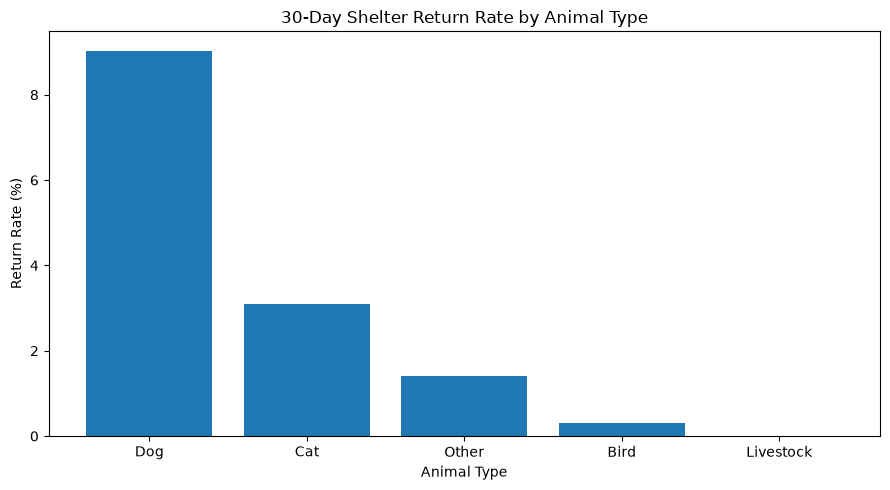

In [13]:
# Visualize 30-day return rates by animal type.
# The chart emphasizes differences in return rates while the underlying
# adoption counts should be considered when interpreting small groups.

plt.figure(figsize=(9, 5))

plt.bar(
    animal_type_summary["Animal Type"],
    animal_type_summary["Return Rate %"]
)

plt.title("30-Day Shelter Return Rate by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Return Rate (%)")

plt.tight_layout()
plt.show()

Key Finding

Dogs had the highest observed 30-day return rate among the major animal groups. Approximately 9.0% of dog adoptions resulted in a return within 30 days, compared with approximately 3.1% of cat adoptions.

This means the observed 30-day return rate for dogs was roughly 2.9 times the rate for cats.

The remaining animal types had substantially fewer adoption events, so their return rates should be interpreted cautiously.

These results describe an association between animal type and 30-day returns and should not be interpreted as evidence that animal type itself causes a return.

Return Rate by Age at Adoption

Age at adoption was grouped into five categories to examine whether 30-day return rates differed across life stages.

The age groups are:

- Under 6 months
- 6–12 months
- 1–3 years
- 3–7 years
- 7+ years

In [14]:
# Summarize adoption volume and 30-day returns by age group.
# Age Group was created during the feature-engineering stage
# using the animal's recorded age at the time of adoption.

age_return_summary = (
    analysis
    .groupby("Age Group", observed=True)
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

# Convert the return rate to a percentage for easier interpretation.

age_return_summary["Return Rate %"] = (
    age_return_summary["Return_Rate"] * 100
)

# Display the results.

age_return_summary[
    ["Age Group", "Adoptions", "Returns", "Return Rate %"]
]

,Age Group,Adoptions,Returns,Return Rate %
0,1–3 years,24376,2308,9.468330
1,3–7 years,9576,938,9.795322
2,6–12 months,8499,587,6.906695
3,7+ years,4709,362,7.687407
4,Under 6 months,36980,1191,3.220660


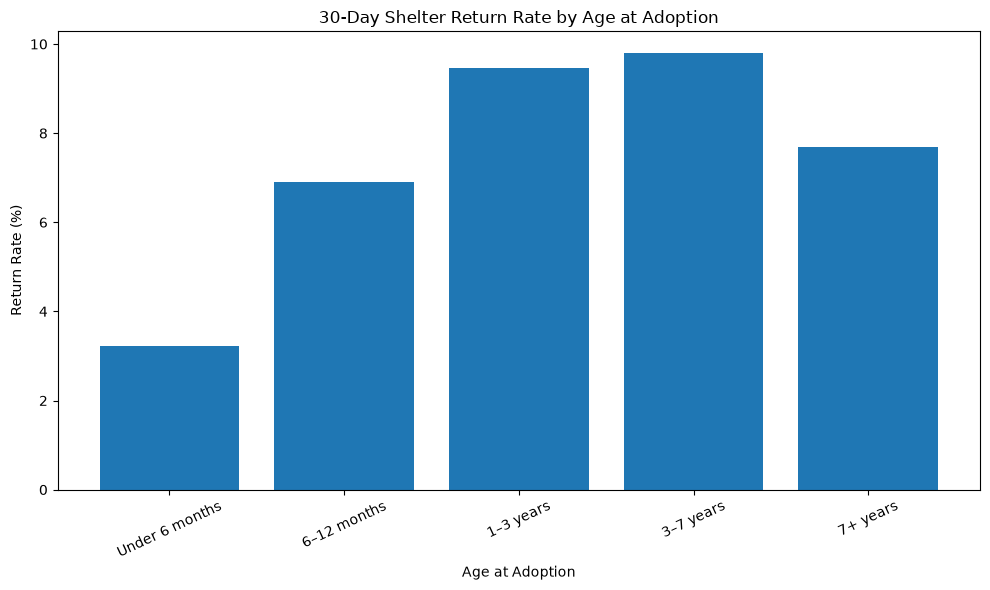

In [15]:
# Define the logical life-stage order for the age groups.
# Reloading the CSV converted Age Group from an ordered categorical
# variable to text, so we restore the intended order for presentation.

age_order = [
    "Under 6 months",
    "6–12 months",
    "1–3 years",
    "3–7 years",
    "7+ years"
]

age_return_summary["Age Group"] = pd.Categorical(
    age_return_summary["Age Group"],
    categories=age_order,
    ordered=True
)

age_return_summary = age_return_summary.sort_values("Age Group")


# Plot return rates in chronological age order so the relationship
# between age at adoption and 30-day returns is easy to see.

plt.figure(figsize=(10, 6))

plt.bar(
    age_return_summary["Age Group"].astype(str),
    age_return_summary["Return Rate %"]
)

plt.title("30-Day Shelter Return Rate by Age at Adoption")
plt.xlabel("Age at Adoption")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

Key Finding

Thirty-day return rates varied substantially by age at adoption.

Animals under 6 months had the lowest observed return rate at **3.2%**. Return rates increased across the older age groups, reaching approximately **9.5% for animals aged 1–3 years** and **9.8% for animals aged 3–7 years**.

The rate declined somewhat among animals aged 7 years or older to **7.7%**, indicating that the relationship between age and return risk was not simply linear.

Animals aged 3–7 years had approximately **three times the observed 30-day return rate** of animals adopted before six months of age.

These results represent descriptive associations and do not establish that age itself causes an adoption to result in a return.

Return Rate by Prior Shelter History

Prior shelter history was examined to determine whether animals with previous recorded shelter intakes had different 30-day return rates after adoption.

The number of previous intakes excludes the intake associated with the current adoption. Animals were grouped into three categories: no previous intakes, one previous intake, and two or more previous intakes.

In [16]:
# Summarize adoption volume and 30-day returns by prior shelter history.
# Previous Intake Group was created during feature engineering from the
# number of shelter intakes recorded before the animal's current stay.

previous_intake_summary = (
    analysis
    .groupby("Previous Intake Group", observed=True)
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

# Convert the return rate to a percentage for easier interpretation.

previous_intake_summary["Return Rate %"] = (
    previous_intake_summary["Return_Rate"] * 100
)

# Display the final-cohort results before creating the visualization.

previous_intake_summary[
    ["Previous Intake Group", "Adoptions", "Returns", "Return Rate %"]
]

,Previous Intake Group,Adoptions,Returns,Return Rate %
0,0,74988,4306,5.742252
1,1,7328,810,11.053493
2,2+,1827,270,14.778325


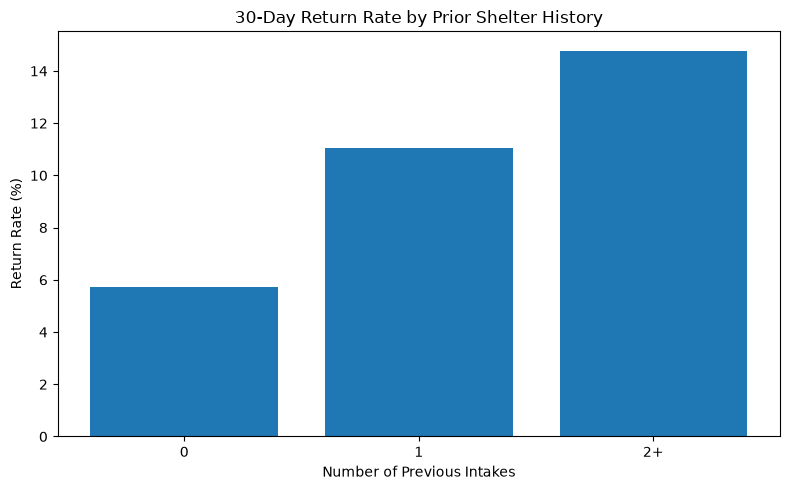

In [17]:
# Define the logical order for previous shelter history so the chart
# progresses from no previous intakes to greater prior shelter exposure.

previous_intake_order = ["0", "1", "2+"]

previous_intake_summary["Previous Intake Group"] = pd.Categorical(
    previous_intake_summary["Previous Intake Group"].astype(str),
    categories=previous_intake_order,
    ordered=True
)

previous_intake_summary = previous_intake_summary.sort_values(
    "Previous Intake Group"
)


# Visualize the relationship between prior shelter history and
# the observed 30-day return rate.

plt.figure(figsize=(8, 5))

plt.bar(
    previous_intake_summary["Previous Intake Group"].astype(str),
    previous_intake_summary["Return Rate %"]
)

plt.title("30-Day Return Rate by Prior Shelter History")
plt.xlabel("Number of Previous Intakes")
plt.ylabel("Return Rate (%)")

plt.tight_layout()
plt.show()

Key Finding

Prior shelter history showed a strong association with 30-day returns.

Animals with no previous recorded intakes had a 5.7% return rate. The rate increased to 11.1% among animals with one previous intake and 14.8% among animals with two or more previous intakes.

Adoption events involving animals with two or more previous intakes therefore had approximately 2.6 times the observed 30-day return rate of adoption events involving animals with no previous recorded intakes.

This pattern suggests that prior shelter history may be useful for identifying adoption events associated with elevated return risk. However, the measure is limited to intake history observable within the available shelter records and should not be interpreted as evidence that previous shelter stays cause future returns.

Time from Intake to Adoption

The length of time between an animal's intake and adoption may also be associated with the likelihood of a subsequent return.

Before grouping length of stay into meaningful categories, the distribution of time from intake to adoption is examined.

In [18]:
# Examine the distribution of time between shelter intake and adoption.
# The existing feature is measured in years, so we convert it to days
# here to make the results easier to interpret.

days_to_adoption = analysis["Years from Intake to Adoption"] * 365.25

# Display summary statistics and the number of missing values.
# This helps us choose meaningful length-of-stay categories before
# comparing return rates.

print("Available records:", f"{days_to_adoption.notna().sum():,}")
print("Missing records:", f"{days_to_adoption.isna().sum():,}")

print("\nDays from intake to adoption:")
print(days_to_adoption.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
))

Available records: 83,514
Missing records: 629

Days from intake to adoption:
count    83514.000000
mean        34.917538
std         61.675048
min          0.000694
25%          5.298611
50%         14.058333
75%         43.024826
90%         79.892083
95%        119.995694
max       1912.938194
Name: Years from Intake to Adoption, dtype: float64


In [19]:
# Convert the existing intake-to-adoption duration from years to days
# so the measure is easier to interpret operationally.

analysis["Days to Adoption"] = (
    analysis["Years from Intake to Adoption"] * 365.25
)


# Group adoption events into practical length-of-stay categories.
# These categories distinguish quick adoptions from progressively
# longer shelter stays while retaining enough observations per group.

stay_bins = [0, 7, 14, 30, 60, np.inf]

stay_labels = [
    "0–7 days",
    "8–14 days",
    "15–30 days",
    "31–60 days",
    "61+ days"
]

analysis["Time to Adoption Group"] = pd.cut(
    analysis["Days to Adoption"],
    bins=stay_bins,
    labels=stay_labels,
    include_lowest=True
)


# Summarize adoption volume and 30-day returns for each
# intake-to-adoption time group.

stay_summary = (
    analysis
    .groupby("Time to Adoption Group", observed=True)
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

stay_summary["Return Rate %"] = (
    stay_summary["Return_Rate"] * 100
)

stay_summary[
    ["Time to Adoption Group", "Adoptions", "Returns", "Return Rate %"]
]

,Time to Adoption Group,Adoptions,Returns,Return Rate %
0,0–7 days,26964,1781,6.605103
1,8–14 days,14638,1062,7.255089
2,15–30 days,13188,936,7.097361
3,31–60 days,15179,838,5.520785
4,61+ days,13545,721,5.322997


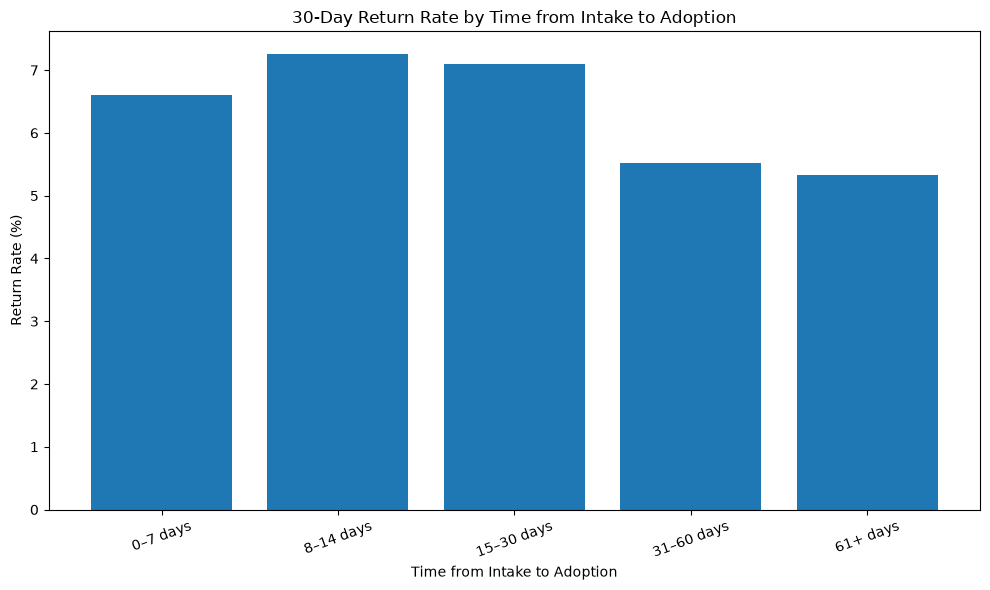

In [20]:
# Visualize 30-day return rates across intake-to-adoption time groups.
# The categories are already ordered from shortest to longest stay.

plt.figure(figsize=(10, 6))

plt.bar(
    stay_summary["Time to Adoption Group"].astype(str),
    stay_summary["Return Rate %"]
)

plt.title("30-Day Return Rate by Time from Intake to Adoption")
plt.xlabel("Time from Intake to Adoption")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Key Finding

The relationship between time from intake to adoption and 30-day returns was not linear.

Animals adopted within 8–14 days had the highest observed return rate at approximately 7.3%, followed by animals adopted within 15–30 days at 7.1%. Animals adopted within the first seven days had a return rate of 6.6%.

Return rates were lower among animals with longer shelter stays, declining to approximately 5.5% for stays of 31–60 days and 5.3% for stays longer than 60 days.

These results do not indicate that longer shelter stays cause lower return rates. Differences in animal characteristics, adoption pathways, foster placement, or other factors may contribute to the observed pattern.

Age and Animal Type

Because dogs and cats have substantially different overall return rates, age was also examined separately within each animal type.

This comparison helps determine whether the relationship between age and 30-day returns remains visible when dogs and cats are evaluated separately.

In [21]:
# Restrict this comparison to dogs and cats because they account for
# the overwhelming majority of adoption events in the dataset.

dog_cat_analysis = analysis[
    analysis["Animal Type"].isin(["Dog", "Cat"])
].copy()


# Calculate adoption counts, returns, and return rates for each
# combination of animal type and age group.

age_type_summary = (
    dog_cat_analysis
    .groupby(
        ["Age Group", "Animal Type"],
        observed=True
    )
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)


# Convert the return rate to a percentage for easier interpretation.

age_type_summary["Return Rate %"] = (
    age_type_summary["Return_Rate"] * 100
)


# Restore the logical age-group order after loading the data from CSV.

age_type_summary["Age Group"] = pd.Categorical(
    age_type_summary["Age Group"],
    categories=age_order,
    ordered=True
)

age_type_summary = age_type_summary.sort_values(
    ["Age Group", "Animal Type"]
)


# Display the results before creating the visualization.

age_type_summary[
    [
        "Age Group",
        "Animal Type",
        "Adoptions",
        "Returns",
        "Return Rate %"
    ]
]

,Age Group,Animal Type,Adoptions,Returns,Return Rate %
8,Under 6 months,Cat,23478,533,2.270210
9,Under 6 months,Dog,13307,655,4.922221
4,6–12 months,Cat,2596,74,2.850539
5,6–12 months,Dog,5700,512,8.982456
0,1–3 years,Cat,5507,262,4.757581
1,1–3 years,Dog,18042,2037,11.290323
2,3–7 years,Cat,2337,138,5.905006
3,3–7 years,Dog,7146,799,11.181080
6,7+ years,Cat,1641,95,5.789153
7,7+ years,Dog,3054,266,8.709889


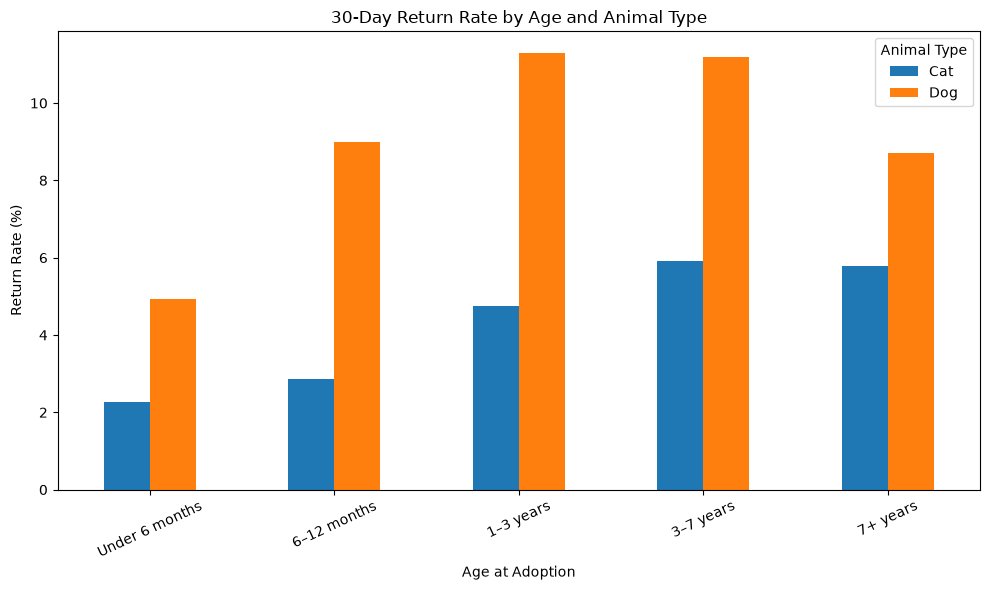

In [22]:
# Reshape the summary table so dogs and cats can be displayed
# side by side within each age group.

age_type_plot = age_type_summary.pivot(
    index="Age Group",
    columns="Animal Type",
    values="Return Rate %"
)


# Create a grouped bar chart to compare dogs and cats
# across the same age-at-adoption categories.

age_type_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("30-Day Return Rate by Age and Animal Type")
plt.xlabel("Age at Adoption")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=25)
plt.legend(title="Animal Type")

plt.tight_layout()
plt.show()

Key Finding

Dogs had higher observed 30-day return rates than cats in every age group examined.

Among dogs, return rates increased from 4.9% for animals under six months to approximately 11.3% for animals aged 1–3 years and 11.2% for animals aged 3–7 years.

Among cats, return rates increased from 2.3% for animals under six months to approximately 5.9% for animals aged 3–7 years.

The persistence of the dog-cat difference within each age group indicates that the higher overall return rate observed among dogs cannot be explained solely by differences in the age distributions of adopted dogs and cats.

Age and animal type are both associated with 30-day shelter returns, although this descriptive analysis does not establish a causal relationship.

Multivariable Analysis

The descriptive analysis identified several characteristics associated with 30-day shelter returns. However, these characteristics may also be related to one another.

A logistic regression model is used to examine whether animal type, age at adoption, prior shelter history, and time from intake to adoption remain associated with 30-day returns when considered simultaneously.

Because an individual animal may appear in more than one adoption event, the statistical analysis will account for repeated observations of the same animal.

In [23]:
# Create a modeling dataset containing only the variables needed
# for the multivariable analysis.
#
# We restrict animal type to dogs and cats because the other animal
# categories contain relatively few adoption events and would provide
# unstable comparisons in the regression model.

model_data = analysis[
    analysis["Animal Type"].isin(["Dog", "Cat"])
][
    [
        "Animal ID",
        "Returned_30",
        "Animal Type",
        "Age Group",
        "Previous Intake Group",
        "Time to Adoption Group"
    ]
].copy()


# Remove rows with missing values in any of the model variables.
# Logistic regression requires complete observations for all predictors
# included in the model.

model_data = model_data.dropna()


# Display the size of the final modeling sample and the distribution
# of the outcome before fitting the model.

print("Modeling observations:", f"{len(model_data):,}")
print("Unique animals:", f"{model_data['Animal ID'].nunique():,}")
print("30-day returns:", f"{model_data['Returned_30'].sum():,}")
print(
    "Return rate:",
    f"{model_data['Returned_30'].mean() * 100:.2f}%"
)

Modeling observations: 82,181
Unique animals: 74,588
30-day returns: 5,324
Return rate: 6.48%


In [25]:
# Convert the binary return outcome to numeric 0/1 values.
# statsmodels requires the dependent variable in logistic regression
# to be numeric rather than boolean or text.

model_data["Returned_30"] = (
    model_data["Returned_30"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    })
)


# Verify that the conversion worked correctly.
# We should see only 0 and 1, with no missing values.

print(model_data["Returned_30"].value_counts())
print("\nMissing outcomes:", model_data["Returned_30"].isna().sum())
print("Data type:", model_data["Returned_30"].dtype)

Returned_30
0    76857
1     5324
Name: count, dtype: int64

Missing outcomes: 0
Data type: int64


In [27]:
# Fit the multivariable logistic regression model.
#
# Each categorical predictor has an explicit reference category,
# making the resulting comparisons easier to interpret.
#
# Cluster-robust standard errors are used because the same animal
# can appear in more than one adoption event.

return_model = smf.logit(
    formula="""
        Returned_30
        ~ C(Q("Animal Type"), Treatment(reference="Cat"))
        + C(Q("Age Group"), Treatment(reference="Under 6 months"))
        + C(Q("Previous Intake Group"), Treatment(reference="0"))
        + C(Q("Time to Adoption Group"), Treatment(reference="0–7 days"))
    """,
    data=model_data
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": model_data["Animal ID"]
    }
)


# Display the full statistical model results.

print(return_model.summary())

Optimization terminated successfully.
         Current function value: 0.227229
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            Returned_30   No. Observations:                82181
Model:                          Logit   Df Residuals:                    82169
Method:                           MLE   Df Model:                           11
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                 0.05295
Time:                        12:21:46   Log-Likelihood:                -18674.
converged:                       True   LL-Null:                       -19718.
Covariance Type:              cluster   LLR p-value:                     0.000
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------

In [28]:
# Convert the logistic regression coefficients from log-odds
# into odds ratios, which are easier to interpret.
#
# We also convert the confidence interval bounds into odds ratios
# and retain the p-values from the fitted model.

odds_ratios = pd.DataFrame({
    "Odds Ratio": np.exp(return_model.params),
    "CI Lower": np.exp(return_model.conf_int()[0]),
    "CI Upper": np.exp(return_model.conf_int()[1]),
    "p-value": return_model.pvalues
})


# Remove the intercept because our substantive interest is in
# comparisons between predictor categories.

odds_ratios = odds_ratios.drop("Intercept")


# Round the results for a cleaner presentation.

odds_ratios = odds_ratios.round({
    "Odds Ratio": 2,
    "CI Lower": 2,
    "CI Upper": 2,
    "p-value": 4
})


# Display the interpretable model results.

odds_ratios

,Odds Ratio,CI Lower,CI Upper,p-value
"C(Q(""Animal Type""), Treatment(reference=""Cat""))[T.Dog]",2.28,2.12,2.45,0.0000
"C(Q(""Age Group""), Treatment(reference=""Under 6 months""))[T.1–3 years]",2.28,2.11,2.46,0.0000
"C(Q(""Age Group""), Treatment(reference=""Under 6 months""))[T.3–7 years]",2.28,2.07,2.51,0.0000
"C(Q(""Age Group""), Treatment(reference=""Under 6 months""))[T.6–12 months]",1.70,1.53,1.89,0.0000
"C(Q(""Age Group""), Treatment(reference=""Under 6 months""))[T.7+ years]",1.87,1.65,2.13,0.0000
"C(Q(""Previous Intake Group""), Treatment(reference=""0""))[T.1]",1.48,1.36,1.60,0.0000
"C(Q(""Previous Intake Group""), Treatment(reference=""0""))[T.2+]",1.75,1.52,2.01,0.0000
"C(Q(""Time to Adoption Group""), Treatment(reference=""0–7 days""))[T.8–14 days]",1.09,1.01,1.18,0.0351
"C(Q(""Time to Adoption Group""), Treatment(reference=""0–7 days""))[T.15–30 days]",1.17,1.07,1.27,0.0003
"C(Q(""Time to Adoption Group""), Treatment(reference=""0–7 days""))[T.31–60 days]",1.11,1.01,1.21,0.0223


In [29]:
# Create readable labels for each regression comparison.
# This replaces the technical statsmodels parameter names with
# descriptions that can be understood without reading the model formula.

model_labels = {
    'C(Q("Animal Type"), Treatment(reference="Cat"))[T.Dog]':
        "Dog vs Cat",

    'C(Q("Age Group"), Treatment(reference="Under 6 months"))[T.6–12 months]':
        "Age 6–12 months vs Under 6 months",

    'C(Q("Age Group"), Treatment(reference="Under 6 months"))[T.1–3 years]':
        "Age 1–3 years vs Under 6 months",

    'C(Q("Age Group"), Treatment(reference="Under 6 months"))[T.3–7 years]':
        "Age 3–7 years vs Under 6 months",

    'C(Q("Age Group"), Treatment(reference="Under 6 months"))[T.7+ years]':
        "Age 7+ years vs Under 6 months",

    'C(Q("Previous Intake Group"), Treatment(reference="0"))[T.1]':
        "1 previous intake vs None",

    'C(Q("Previous Intake Group"), Treatment(reference="0"))[T.2+]':
        "2+ previous intakes vs None",

    'C(Q("Time to Adoption Group"), Treatment(reference="0–7 days"))[T.8–14 days]':
        "8–14 days vs 0–7 days",

    'C(Q("Time to Adoption Group"), Treatment(reference="0–7 days"))[T.15–30 days]':
        "15–30 days vs 0–7 days",

    'C(Q("Time to Adoption Group"), Treatment(reference="0–7 days"))[T.31–60 days]':
        "31–60 days vs 0–7 days",

    'C(Q("Time to Adoption Group"), Treatment(reference="0–7 days"))[T.61+ days]':
        "61+ days vs 0–7 days"
}


# Replace the technical parameter names with the readable labels
# and reset the index so the comparison becomes a normal column.

model_results = odds_ratios.rename(
    index=model_labels
).reset_index()

model_results = model_results.rename(
    columns={"index": "Comparison"}
)


# Display the final presentation-ready regression table.

model_results

,Comparison,Odds Ratio,CI Lower,CI Upper,p-value
0,Dog vs Cat,2.28,2.12,2.45,0.0000
1,Age 1–3 years vs Under 6 months,2.28,2.11,2.46,0.0000
2,Age 3–7 years vs Under 6 months,2.28,2.07,2.51,0.0000
3,Age 6–12 months vs Under 6 months,1.70,1.53,1.89,0.0000
4,Age 7+ years vs Under 6 months,1.87,1.65,2.13,0.0000
5,1 previous intake vs None,1.48,1.36,1.60,0.0000
6,2+ previous intakes vs None,1.75,1.52,2.01,0.0000
7,8–14 days vs 0–7 days,1.09,1.01,1.18,0.0351
8,15–30 days vs 0–7 days,1.17,1.07,1.27,0.0003
9,31–60 days vs 0–7 days,1.11,1.01,1.21,0.0223


Multivariable Results

The multivariable model generally supported the patterns observed in the descriptive analysis.

After accounting for age, prior shelter history, and time from intake to adoption, dogs had 2.28 times the odds of a 30-day return compared with cats.

Age also remained strongly associated with returns. Compared with animals under six months old, animals aged 1–3 years and 3–7 years each had approximately 2.28 times the odds of a 30-day return.

Prior shelter history remained associated with elevated return odds after accounting for the other variables. Animals with one previous intake had 1.48 times the odds of a return compared with animals with no previous recorded intakes, while animals with two or more previous intakes had 1.75 times the odds.

Time from intake to adoption showed a smaller and less consistent relationship. Compared with animals adopted within seven days, animals adopted after 15–30 days had 1.17 times the odds of a return, while animals adopted after more than 60 days had lower odds of return, with an odds ratio of 0.83.

These estimates represent adjusted associations rather than causal effects. The model accounts only for the variables included in the analysis, and other characteristics not captured in the available data may contribute to shelter returns.

Conclusions

This analysis examined 84,143 adoption events with a complete 30-day follow-up period to identify characteristics associated with short-term shelter returns.

Several patterns emerged:

1. Animal type was strongly associated with returns. Dogs had a 9.0% observed return rate compared with 3.1% for cats. After accounting for the other variables in the model, dogs had 2.28 times the odds of a 30-day return compared with cats.

2. Age at adoption was also associated with returns. Animals under six months had the lowest observed return rate at 3.2%, while animals aged 1–3 years and 3–7 years had return rates near 9.5–9.8%. These age differences remained after accounting for the other modeled characteristics.

3. Prior shelter history was associated with elevated return risk. The observed return rate increased from 5.7% among animals with no previous recorded intakes to 11.1% with one previous intake and 14.8% with two or more. Prior intake history remained associated with higher return odds in the multivariable model.

4. Time from intake to adoption showed a smaller and less consistent relationship with returns. Return rates were highest among animals adopted within 8–30 days and lower among animals with stays longer than 30 days.

Taken together, the results suggest that animal type, age, and prior shelter history may be useful characteristics for identifying adoption events associated with elevated short-term return risk.

These findings could help support targeted post-adoption follow-up, additional adopter support, or further investigation into the circumstances surrounding returns.

Limitations

This analysis is observational and identifies associations rather than causal relationships.

Several limitations should be considered when interpreting the results:

- The analysis is based on records from a single shelter system, so the findings may not generalize to other shelters or communities.
- Prior shelter history reflects only intake events observable within the available dataset. An animal categorized as having no previous intakes may have had shelter history outside the available records.
- Some potentially important factors are not captured in the dataset, including adopter characteristics, household environment, behavioral concerns, and the specific reason an animal was returned.
- Age is based on the shelter's recorded age and may be estimated rather than known precisely.
- Some animals appear in multiple adoption events. The multivariable analysis used cluster-robust standard errors by Animal ID to account for repeated observations of the same animal.
- The 30-day outcome captures short-term returns only and does not represent all returns that may occur later.
- Associations from the logistic regression should not be interpreted as evidence that any characteristic causes an adoption to fail.

The results are best interpreted as a way to identify patterns that may warrant additional investigation or targeted support rather than as a deterministic prediction of whether an individual adoption will result in a return.

Methods and Tools

This project was completed in Python using Pandas for data preparation and analysis, Matplotlib for visualization, and Statsmodels for statistical modeling.

The analysis workflow included:

- Cleaning and validating shelter intake and outcome records
- Linking adoption events to subsequent shelter intakes
- Defining a 30-day return outcome
- Restricting the analysis to adoption events with a complete 30-day follow-up period
- Engineering features for age, prior shelter history, and time from intake to adoption
- Comparing return rates across animal characteristics
- Examining interactions between age and animal type
- Fitting a multivariable logistic regression model
- Using cluster-robust standard errors to account for animals appearing in multiple adoption events

The final analytical cohort contained 84,143 adoption events.